In [1082]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import matplotlib
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

import re

font_path = 'C:/Windows/Fonts/gulim.ttc'
font = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc("font",family=font)

In [1083]:
df_team = pd.read_csv("../../../EDA/Merge/data/result data/Final DF.csv")  # Year, Nation, ..., DEF_INDEX 등

# 예시: 경기 단위 데이터
df_match = pd.read_csv("./../data/matches_1930_2022.csv")  

In [1084]:
df_team.columns
df_team=df_team[['Year', 'Nation','Eng_Nation','Q_WR', 'Q_GR',
       'F_Rank', 'F_Point', 'F_Rd', 'F_Pd', 'Avg_Apps', 'Avg_Age','Avg_Famous', 'FS_0', 'FS_1', 'FS_2', 'FS_3', 'FS_4', 'FS_5', 'FS_6',
       'FS_7', 'FS_8', 'FS_9', 'FS_10', 'FS_11', 'FS_12', 'FS_13', 'FS_14']]

In [1085]:
df_match = df_match[['Year','home_team','away_team','home_score','away_score','Score']]
df_fin = df_match

In [1086]:
country_map = {
    "브라질": "Brazil",
    "독일": "Germany",
    "터키": "Türkiye",
    "대한민국": "Korea Republic",
    "스페인": "Spain",
    "잉글랜드": "England",
    "세네갈": "Senegal",
    "미국": "United States",
    "일본": "Japan",
    "덴마크": "Denmark",
    "멕시코": "Mexico",
    "아일랜드": "Republic of Ireland",
    "스웨덴": "Sweden",
    "벨기에": "Belgium",
    "이탈리아": "Italy",
    "파라과이": "Paraguay",
    "남아프리카 공화국": "South Africa",
    "아르헨티나": "Argentina",
    "코스타리카": "Costa Rica",
    "카메룬": "Cameroon",
    "포르투갈": "Portugal",
    "러시아": "Russia",
    "크로아티아": "Croatia",
    "에콰도르": "Ecuador",
    "폴란드": "Poland",
    "우루과이": "Uruguay",
    "나이지리아": "Nigeria",
    "프랑스": "France",
    "튀니지": "Tunisia",
    "슬로베니아": "Slovenia",
    "중국": "China PR",
    "사우디아라비아": "Saudi Arabia",
    "우크라이나": "Ukraine",
    "스위스": "Switzerland",
    "네덜란드": "Netherlands",
    "가나": "Ghana",
    "호주": "Australia",
    "코트디부아르": "Côte d'Ivoire",
    "체코": "Czech Republic",
    "앙골라": "Angola",
    "이란": "IR Iran",
    "트리니다드 토바고": "Trinidad and Tobago",
    "토고": "Togo",
    "세르비아 몬테네그로": "Serbia and Montenegro",
    "칠레": "Chile",
    "슬로바키아": "Slovakia",
    "뉴질랜드": "New Zealand",
    "세르비아": "Serbia",
    "그리스": "Greece",
    "알제리": "Algeria",
    "온두라스": "Honduras",
    "북한": "Korea DPR",
    "콜롬비아": "Colombia",
    "보스니아 헤르체고비나": "Bosnia and Herzegovina",
    "페루": "Peru",
    "모로코": "Morocco",
    "아이슬란드": "Iceland",
    "이집트": "Egypt",
    "파나마": "Panama",
    "웨일스": "Wales",
    "캐나다": "Canada",
    "카타르": "Qatar",
}

In [1087]:


# ---------------------------
# 0️⃣ 2002년 이후 경기만 선택
# ---------------------------
df_match_filtered = df_match[df_match['Year'] >= 2002].reset_index(drop=True)

# ---------------------------
# 1️⃣ 팀 데이터에 영어 이름 컬럼 추가 (country_map 사용)
# ---------------------------
df_team['Eng_Nation'] = df_team['Nation'].map(country_map)

# ---------------------------
# 2️⃣ Year + Eng_Nation 기준 인덱스 설정
# ---------------------------
df_team_renamed = df_team.set_index(['Year', 'Eng_Nation'])

# ---------------------------
# 3️⃣ 매핑 실패 팀 기록용
# ---------------------------
missing_teams = set()

# ---------------------------
# 4️⃣ 점수 문자열에서 최종 결과 계산
# ---------------------------
def parse_result_from_score(score_str):
    """
    score_str 예시: "3–3", "(4) 3–3 (2)", "2–1"
    반환: 1 = 홈승, 0 = 무승부, -1 = 홈패
    """
    # 정규/연장 점수 추출
    main_match = re.search(r'(\d+)\s*–\s*(\d+)', score_str)
    if not main_match:
        return None  # 점수 형식 이상
    
    home_main = int(main_match.group(1))
    away_main = int(main_match.group(2))
    
    # 점수가 다르면 정규/연장으로 승패 결정
    if home_main > away_main:
        return 1
    elif home_main < away_main:
        return -1
    else:
        # 동점이면 승부차기 점수 확인
        pens = re.findall(r'\((\d+)\)', score_str)
        if len(pens) == 2:
            home_pen = int(pens[0])
            away_pen = int(pens[1])
            if home_pen > away_pen:
                return 1
            elif home_pen < away_pen:
                return -1
        # 승부차기 없거나 동점이면 무승부
        return 0

# ---------------------------
# 5️⃣ 홈/어웨이 팀 특징 매핑 함수
# ---------------------------
def map_team_features_safe(row):
    year = row['Year']
    home = row['home_team']
    away = row['away_team']
    
    # 홈팀 특징
    try:
        home_feat = df_team_renamed.loc[(year, home)].add_prefix("Home_")
    except KeyError:
        missing_teams.add(home)
        home_feat = pd.Series(dtype=float)
    
    # 어웨이팀 특징
    try:
        away_feat = df_team_renamed.loc[(year, away)].add_prefix("Away_")
    except KeyError:
        missing_teams.add(away)
        away_feat = pd.Series(dtype=float)
    
    # 경기 결과 계산 (홈승=1, 무승부=0, 홈패=-1)
    result = parse_result_from_score(row['Score'])

    return pd.concat([pd.Series({'Year': year}), home_feat, away_feat, pd.Series({'Result': result})])

# ---------------------------
# 6️⃣ 적용
# ---------------------------
df_final = df_match_filtered.apply(map_team_features_safe, axis=1).reset_index(drop=True)

# ---------------------------
# 7️⃣ 매핑 실패 팀 확인
# ---------------------------
if missing_teams:
    print("매핑이 안 된 팀:", missing_teams)

# ---------------------------
# 8️⃣ 결과 확인
# ---------------------------
print(df_final.head())


   Year Home_Nation  Home_Q_WR  Home_Q_GR  Home_F_Rank  Home_F_Point  \
0  2022       아르헨티나       0.52   3.888889         8.33       1654.10   
1  2022       크로아티아       0.54   1.479452        11.00       1620.42   
2  2022         프랑스       0.63   2.830189         2.67       1741.10   
3  2022       아르헨티나       0.52   3.888889         8.33       1654.10   
4  2022         모로코       0.51   3.055556        38.33       1470.74   

   Home_F_Rd  Home_F_Pd  Home_Avg_Apps  Home_Avg_Age  ...  Away_FS_6  \
0       6.58     190.35        0.50000         27.81  ...      71.88   
1      -4.00     592.92        0.46154         27.42  ...      66.91   
2     -10.66     644.77        0.65385         26.69  ...      66.91   
3       6.58     190.35        0.50000         27.81  ...      69.46   
4     -28.00     938.74        0.23077         26.31  ...      68.76   

   Away_FS_7  Away_FS_8  Away_FS_9  Away_FS_10  Away_FS_11  Away_FS_12  \
0      68.46      74.35      68.04       73.38       17.92  

In [1088]:
df = df_final
df.columns

Index(['Year', 'Home_Nation', 'Home_Q_WR', 'Home_Q_GR', 'Home_F_Rank',
       'Home_F_Point', 'Home_F_Rd', 'Home_F_Pd', 'Home_Avg_Apps',
       'Home_Avg_Age', 'Home_Avg_Famous', 'Home_FS_0', 'Home_FS_1',
       'Home_FS_2', 'Home_FS_3', 'Home_FS_4', 'Home_FS_5', 'Home_FS_6',
       'Home_FS_7', 'Home_FS_8', 'Home_FS_9', 'Home_FS_10', 'Home_FS_11',
       'Home_FS_12', 'Home_FS_13', 'Home_FS_14', 'Away_Nation', 'Away_Q_WR',
       'Away_Q_GR', 'Away_F_Rank', 'Away_F_Point', 'Away_F_Rd', 'Away_F_Pd',
       'Away_Avg_Apps', 'Away_Avg_Age', 'Away_Avg_Famous', 'Away_FS_0',
       'Away_FS_1', 'Away_FS_2', 'Away_FS_3', 'Away_FS_4', 'Away_FS_5',
       'Away_FS_6', 'Away_FS_7', 'Away_FS_8', 'Away_FS_9', 'Away_FS_10',
       'Away_FS_11', 'Away_FS_12', 'Away_FS_13', 'Away_FS_14', 'Result'],
      dtype='object')

In [1089]:
# 홈/어웨이 컬럼 분리
home_cols = [col for col in df.columns if col.startswith('Home_')]
away_cols = [col for col in df.columns if col.startswith('Away_')]

# 컬럼 이름 접두사 바꾸기
home_rename = {col: col.replace('Home_', 'Away_') for col in home_cols}
away_rename = {col: col.replace('Away_', 'Home_') for col in away_cols}

# 데이터 복사 후 컬럼 교체
df_swapped = df.copy()
df_swapped = df_swapped.rename(columns={**home_rename, **away_rename})

# Result 반대로 바꾸기
df_swapped['Result'] = df_swapped['Result'].replace({1: -1, -1: 1, 0: 0})

# 원본과 합치기
df_expanded = pd.concat([df, df_swapped], ignore_index=True)

print(df_expanded.shape)
print(df_expanded.head())


(768, 52)
   Year Home_Nation  Home_Q_WR  Home_Q_GR  Home_F_Rank  Home_F_Point  \
0  2022       아르헨티나       0.52   3.888889         8.33       1654.10   
1  2022       크로아티아       0.54   1.479452        11.00       1620.42   
2  2022         프랑스       0.63   2.830189         2.67       1741.10   
3  2022       아르헨티나       0.52   3.888889         8.33       1654.10   
4  2022         모로코       0.51   3.055556        38.33       1470.74   

   Home_F_Rd  Home_F_Pd  Home_Avg_Apps  Home_Avg_Age  ...  Away_FS_6  \
0       6.58     190.35        0.50000         27.81  ...      71.88   
1      -4.00     592.92        0.46154         27.42  ...      66.91   
2     -10.66     644.77        0.65385         26.69  ...      66.91   
3       6.58     190.35        0.50000         27.81  ...      69.46   
4     -28.00     938.74        0.23077         26.31  ...      68.76   

   Away_FS_7  Away_FS_8  Away_FS_9  Away_FS_10  Away_FS_11  Away_FS_12  \
0      68.46      74.35      68.04       73.38    

In [1090]:
home_cols = [col for col in df_final.columns if col.startswith('Home_')]
away_cols = [col for col in df_final.columns if col.startswith('Away_')]

# Nation 같은 문자열 컬럼 제외
home_cols = [c for c in home_cols if c not in ["Home_Nation"]]
away_cols = [c for c in away_cols if c not in ["Away_Nation"]]

# 공통 지표 이름 추출 (Home_ 접두사 제거)
metrics = [col.replace("Home_", "") for col in home_cols]

diff_data = {}

for metric in metrics:
    home_col = f"Home_{metric}"
    away_col = f"Away_{metric}"
    
    # 두 컬럼이 존재하고 수치형일 때만 처리
    if home_col in df_final.columns and away_col in df_final.columns:
        if pd.api.types.is_numeric_dtype(df_final[home_col]) and pd.api.types.is_numeric_dtype(df_final[away_col]):
            diff_data[metric] = df_final[home_col] - df_final[away_col]

# 결과 컬럼 추가
diff_data["Result"] = df_final["Result"]
diff_data["Year"] = df_final["Year"]


# Home, Away 팀 한글 → 영어 매핑
diff_data["Home_Eng_Nation"] = df_final["Home_Nation"].map(country_map)
diff_data["Away_Eng_Nation"] = df_final["Away_Nation"].map(country_map)

# 최종 데이터프레임 생성
df_diff = pd.DataFrame(diff_data)

print(df_diff.head())


   Q_WR      Q_GR  F_Rank  F_Point   F_Rd    F_Pd  Avg_Apps  Avg_Age  \
0 -0.11  1.058700    5.66   -87.00  17.24 -454.42  -0.15385     1.12   
1  0.03 -1.576104  -27.33   149.68  24.00 -345.82   0.23077     1.11   
2  0.12 -0.225367  -35.66   270.36  17.34 -293.97   0.42308     0.38   
3 -0.02  2.409437   -2.67    33.68  10.58 -402.57   0.03846     0.39   
4 -0.16 -0.476359   32.66  -186.23 -28.17  528.27  -0.38461    -0.57   

   Avg_Famous  FS_0  ...  FS_9  FS_10  FS_11  FS_12  FS_13  FS_14  Result  \
0           2 -1.34  ...  1.69  -1.96  -0.25  -1.94  -0.90   2.04       1   
1           1  0.76  ...  1.41   0.62  -5.60   3.38   7.11   1.59       1   
2           5  7.76  ...  2.95   5.73  -2.80   9.47  11.02   3.01       1   
3           6  5.66  ...  3.23   3.15   2.55   4.15   3.01   3.46       1   
4          -9 -5.61  ... -6.35  -1.07   2.82  -5.97  -6.29  -4.42       1   

   Year  Home_Eng_Nation  Away_Eng_Nation  
0  2022        Argentina           France  
1  2022         

In [1091]:
df_diff = df_diff[df_diff['Result'] != 0]
df_diff['Result'].unique()

array([ 1, -1])

In [1092]:
df_diff.to_csv('./../data/before_record.csv')

---
results 데이터

In [1093]:
df_record = pd.read_csv('./../data/results.csv')
df_record.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48532 entries, 0 to 48531
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        48532 non-null  object
 1   home_team   48532 non-null  object
 2   away_team   48532 non-null  object
 3   home_score  48532 non-null  int64 
 4   away_score  48532 non-null  int64 
 5   tournament  48532 non-null  object
 6   city        48532 non-null  object
 7   country     48532 non-null  object
 8   neutral     48532 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 3.0+ MB


In [1094]:
# 년도 범위
df_record = df_record[df_record['date'] > '1980-01-01']

In [1095]:
df_record.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36443 entries, 12089 to 48531
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        36443 non-null  object
 1   home_team   36443 non-null  object
 2   away_team   36443 non-null  object
 3   home_score  36443 non-null  int64 
 4   away_score  36443 non-null  int64 
 5   tournament  36443 non-null  object
 6   city        36443 non-null  object
 7   country     36443 non-null  object
 8   neutral     36443 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 2.5+ MB


In [1096]:
# # 세부 리그 대략적인 큰 범위로 축소
# def categorize_tournament(t):
#     if t == "FIFA World Cup":
#         return "World Cup "
#     elif t == "FIFA World Cup qualification":
#         return "World Cup Qualifiers"
#     elif "Euro" in t or "UEFA Nations League" in t:
#         return "Europe"
#     elif "AFC" in t or "Asian" in t or "EAFF" in t or "SAFF" in t or "AFF" in t or "CAFA" in t or "ASEAN" in t:
#         return "Asia"
#     elif "Africa" in t or "COSAFA" in t or "CECAFA" in t or "UNIFFAC" in t or "UDEAC" in t:
#         return "Africa"
#     elif "Copa" in t or "Gold Cup" in t or "CONCACAF" in t or "CONMEBOL" in t:
#         return "Americas"
#     elif "Oceania" in t or "Pacific" in t:
#         return "Oceania"
#     elif "Friendly" in t:
#         return "Friendly"
#     else:
#         return "Other/Regional"

# df_record["tournament_category"] = df_record["tournament"].apply(categorize_tournament)

In [1097]:
# df_record['tournament_category'].unique()
# df_record.loc[df_record['tournament_category'] == 'World Cup ', 'tournament_category'] = 'World Cup Qualifiers'
# df_record['tournament_category'].unique()

In [1098]:
# index_to_drop = df_record[df_record['tournament_category'].isin(['Other/Regional', 'World Cup Qualifiers'])].index
# df_record = df_record.drop(index=index_to_drop)

In [1099]:
# df_record['tournament_category'].unique()


In [1100]:
df_record = df_record.drop(['city', 'country', 'tournament', 'neutral'], axis=1)

In [1101]:
df_record

,date,home_team,away_team,home_score,away_score
12089,1980-01-06,Sierra Leone,Ghana,2,4
12090,1980-01-16,Cyprus,Greece,1,1
12091,1980-01-19,Congo,Ivory Coast,2,0
12092,1980-01-20,Congo,Ivory Coast,0,2
12093,1980-01-23,Spain,Netherlands,1,0
...,...,...,...,...,...
48527,2025-09-09,Bosnia and Herzegovina,Austria,1,2
48528,2025-09-09,Cyprus,Romania,2,2
48529,2025-09-09,Norway,Moldova,11,1
48530,2025-09-09,Albania,Latvia,1,0


In [1102]:
df_record["home_win"] = np.sign(df_record["home_score"] - df_record["away_score"])

df_record

,date,home_team,away_team,home_score,away_score,home_win
12089,1980-01-06,Sierra Leone,Ghana,2,4,-1
12090,1980-01-16,Cyprus,Greece,1,1,0
12091,1980-01-19,Congo,Ivory Coast,2,0,1
12092,1980-01-20,Congo,Ivory Coast,0,2,-1
12093,1980-01-23,Spain,Netherlands,1,0,1
...,...,...,...,...,...,...
48527,2025-09-09,Bosnia and Herzegovina,Austria,1,2,-1
48528,2025-09-09,Cyprus,Romania,2,2,0
48529,2025-09-09,Norway,Moldova,11,1,1
48530,2025-09-09,Albania,Latvia,1,0,1


In [1103]:
df_count = df_record.drop(['home_score', 'away_score'], axis=1)

In [1104]:
df_count = df_count.drop(df_count[df_count['home_win'] == 0].index, axis=0)
df_count

,date,home_team,away_team,home_win
12089,1980-01-06,Sierra Leone,Ghana,-1
12091,1980-01-19,Congo,Ivory Coast,1
12092,1980-01-20,Congo,Ivory Coast,-1
12093,1980-01-23,Spain,Netherlands,1
12094,1980-01-26,Nigeria,Liberia,1
...,...,...,...,...
48526,2025-09-09,Hungary,Portugal,-1
48527,2025-09-09,Bosnia and Herzegovina,Austria,-1
48529,2025-09-09,Norway,Moldova,1
48530,2025-09-09,Albania,Latvia,1


In [1105]:
# 날짜 → 연도
df_count["year"] = df_count["date"].str[:4].astype(int)

df_count = df_count.drop('date', axis=1)

In [1106]:
df_count

,home_team,away_team,home_win,year
12089,Sierra Leone,Ghana,-1,1980
12091,Congo,Ivory Coast,1,1980
12092,Congo,Ivory Coast,-1,1980
12093,Spain,Netherlands,1,1980
12094,Nigeria,Liberia,1,1980
...,...,...,...,...
48526,Hungary,Portugal,-1,2025
48527,Bosnia and Herzegovina,Austria,-1,2025
48529,Norway,Moldova,1,2025
48530,Albania,Latvia,1,2025


In [1107]:
df_copy = df_count.copy()
df_copy

,home_team,away_team,home_win,year
12089,Sierra Leone,Ghana,-1,1980
12091,Congo,Ivory Coast,1,1980
12092,Congo,Ivory Coast,-1,1980
12093,Spain,Netherlands,1,1980
12094,Nigeria,Liberia,1,1980
...,...,...,...,...
48526,Hungary,Portugal,-1,2025
48527,Bosnia and Herzegovina,Austria,-1,2025
48529,Norway,Moldova,1,2025
48530,Albania,Latvia,1,2025


In [1108]:
df_copy['home_team'] = df_count['away_team']
df_copy['away_team'] = df_count['home_team']
df_copy['home_win'] = df_copy['home_win'].apply(lambda x: -1 if x == 1 else 1)

In [1109]:
df_copy

,home_team,away_team,home_win,year
12089,Ghana,Sierra Leone,1,1980
12091,Ivory Coast,Congo,-1,1980
12092,Ivory Coast,Congo,1,1980
12093,Netherlands,Spain,-1,1980
12094,Liberia,Nigeria,-1,1980
...,...,...,...,...
48526,Portugal,Hungary,1,2025
48527,Austria,Bosnia and Herzegovina,1,2025
48529,Moldova,Norway,-1,2025
48530,Latvia,Albania,-1,2025


In [1110]:
df_count = pd.concat([df_count, df_copy], axis=0).reset_index(drop=True)

---
matches 데이터

In [1111]:
df_fin["home_win"] = (df_fin["home_score"] > df_fin["away_score"]).map({True: 1, False: -1})
df_fin[df_fin['home_win']==0]

,Year,home_team,away_team,home_score,away_score,Score,home_win


In [1112]:
df_fin = df_fin.drop(['home_score', 'away_score', 'Score',], axis=1)

In [1113]:
df_fin

,Year,home_team,away_team,home_win
0,2022,Argentina,France,-1
1,2022,Croatia,Morocco,1
2,2022,France,Morocco,1
3,2022,Argentina,Croatia,1
4,2022,Morocco,Portugal,1
...,...,...,...,...
959,1930,Argentina,France,1
960,1930,Yugoslavia,Brazil,1
961,1930,Romania,Peru,1
962,1930,United States,Belgium,1


In [1114]:
# 년도 범위
df_fin = df_fin[df_fin['Year'] >= 1980]

In [1115]:
df_copy2 = df_fin.copy()
df_copy2

,Year,home_team,away_team,home_win
0,2022,Argentina,France,-1
1,2022,Croatia,Morocco,1
2,2022,France,Morocco,1
3,2022,Argentina,Croatia,1
4,2022,Morocco,Portugal,1
...,...,...,...,...
651,1982,Hungary,El Salvador,1
652,1982,Scotland,New Zealand,1
653,1982,Italy,Poland,-1
654,1982,Brazil,Soviet Union,1


In [1116]:
df_copy2['home_team'] = df_fin['away_team']
df_copy2['away_team'] = df_fin['home_team']
df_copy2['home_win'] = df_fin['home_win'].apply(lambda x: -1 if x == 1 else 1)

In [1117]:
df_copy2

,Year,home_team,away_team,home_win
0,2022,France,Argentina,1
1,2022,Morocco,Croatia,-1
2,2022,Morocco,France,-1
3,2022,Croatia,Argentina,-1
4,2022,Portugal,Morocco,-1
...,...,...,...,...
651,1982,El Salvador,Hungary,-1
652,1982,New Zealand,Scotland,-1
653,1982,Poland,Italy,1
654,1982,Soviet Union,Brazil,-1


In [1118]:
df_fin = pd.concat([df_fin, df_copy2], axis=0).reset_index(drop=True)

---
count + fin

In [1119]:
df_fin['home_team'].unique(), df_count['home_team'].unique()

(array(['Argentina', 'Croatia', 'France', 'Morocco', 'England',
        'Netherlands', 'Portugal', 'Japan', 'Brazil', 'Korea Republic',
        'Ghana', 'Cameroon', 'Serbia', 'Canada', 'Costa Rica', 'Australia',
        'Tunisia', 'Saudi Arabia', 'Poland', 'Ecuador', 'IR Iran', 'Wales',
        'Belgium', 'Spain', 'Qatar', 'Switzerland', 'Uruguay', 'Germany',
        'Denmark', 'Mexico', 'Senegal', 'United States', 'Sweden',
        'Russia', 'Colombia', 'Panama', 'Iceland', 'Nigeria', 'Peru',
        'Egypt', 'Algeria', 'Bosnia and Herzegovina', 'Honduras', 'Italy',
        'Greece', "Côte d'Ivoire", 'Chile', 'Paraguay', 'Korea DPR',
        'Slovakia', 'Slovenia', 'South Africa', 'New Zealand', 'Ukraine',
        'Togo', 'Czech Republic', 'Serbia and Montenegro', 'Angola',
        'Trinidad and Tobago', 'Türkiye', 'China PR',
        'Republic of Ireland', 'Romania', 'Scotland', 'FR Yugoslavia',
        'Jamaica', 'Bulgaria', 'Bolivia', 'Norway', 'West Germany',
        'Yugoslavia',

In [1120]:
country_map = {
    'Korea Republic': 'South Korea',
    'Korea DPR': 'North Korea',
    'IR Iran': 'Iran',
    "Côte d'Ivoire": 'Ivory Coast',
    'Türkiye': 'Turkey',
    'United States': 'United States',
    'Serbia and Montenegro': 'Serbia',
    'China PR': 'China',
    'German DR': 'Germany',
    'United States Virgin Islands': 'United States',
    'DR Congo': 'Congo',
    'Soviet Union': 'Russia',
    'Czechoslovakia': 'Czech Republic',
}

# before_record 기준 컬럼 변환
df_fin['home_team'] = df_fin['home_team'].map(lambda x: country_map.get(x, x))
df_fin['away_team'] = df_fin['away_team'].map(lambda x: country_map.get(x, x))

df_fin = df_fin.rename(columns={'Year': 'year'})
df_fin

,year,home_team,away_team,home_win
0,2022,Argentina,France,-1
1,2022,Croatia,Morocco,1
2,2022,France,Morocco,1
3,2022,Argentina,Croatia,1
4,2022,Morocco,Portugal,1
...,...,...,...,...
1307,1982,El Salvador,Hungary,-1
1308,1982,New Zealand,Scotland,-1
1309,1982,Poland,Italy,1
1310,1982,Russia,Brazil,-1


In [1121]:
import pandas as pd

fin_only = pd.merge(df_fin, df_count, on=['year','home_team','away_team','home_win'], how='left', indicator=True)
fin_only = fin_only[fin_only['_merge'] == 'left_only']
fin_only = fin_only.drop(columns=['_merge'])

df_all = pd.concat([df_count, fin_only], ignore_index=True)

In [1122]:
# 두 데이터프레임 합치기
df_all = pd.concat([df_count, fin_only], ignore_index=True)

# 정렬
df_all = df_all.sort_values(by=['year', 'home_team', 'away_team'])

In [1123]:
df_all

,home_team,away_team,home_win,year
339,Albania,Austria,-1,1980
28040,Albania,Austria,-1,1980
28010,Albania,Bulgaria,-1,1980
203,Albania,Finland,1,1980
69,Alderney,Guernsey,-1,1980
...,...,...,...,...
27325,Zanzibar,Kenya,1,2025
27319,Zanzibar,Tanzania,1,2025
55396,Zimbabwe,Benin,-1,2025
27520,Zimbabwe,Burkina Faso,-1,2025


In [1124]:
# 년도 범위 (누적)
# 1982-2001 ⇒ 2002 전적으로 들어감
# 1985-2005 ⇒ 2006 전적으로 들어감
# 1989-2009 ⇒ 2010 전적으로 들어감
# 1993-2013 ⇒ 2014 전적으로 들어감
# 1997-2017 ⇒ 2018 전적으로 들어감
# 2001-2021 ⇒ 2022 전적으로 들어감
# 2005-2025 ⇒ 2026 전적으로 들어감

years = [2002, 2006, 2010, 2014, 2018, 2022, 2026]

df_list = []
for year in years:
    df_year = df_all[(df_all['year'] >= year - 20) & (df_all['year'] < year)].copy()
    df_year['year'] = year 
    df_list.append(df_year)

df_all_new = pd.concat(df_list, axis=0).reset_index(drop=True)

In [1125]:
df_all_new

,home_team,away_team,home_win,year
0,Albania,Austria,-1,2002
1,Albania,Turkey,-1,2002
2,Alderney,Guernsey,-1,2002
3,Algeria,Austria,-1,2002
4,Algeria,Chile,1,2002
...,...,...,...,...
181621,Zanzibar,Kenya,1,2026
181622,Zanzibar,Tanzania,1,2026
181623,Zimbabwe,Benin,-1,2026
181624,Zimbabwe,Burkina Faso,-1,2026


In [1126]:
# 홈팀 승리 횟수
df_win_count = df_all_new[df_all_new['home_win'] == 1].groupby(
    ['year', 'home_team', 'away_team']
).size().reset_index(name='win_count')

# 홈팀 vs 어웨이팀 총 경기 수
df_total_count = df_all_new.groupby(
    ['year', 'home_team', 'away_team']
).size().reset_index(name='total_count')

# 합치고 홈승 확률 계산
df_rate = pd.merge(df_total_count, df_win_count, on=['year', 'home_team', 'away_team'], how='left')

# NaN -> 0
df_rate['win_count'] = df_rate['win_count'].fillna(0)

# 홈승률 계산
df_rate['home_rate'] = df_rate['win_count'] / df_rate['total_count']

# 최종 선택
df_rate = df_rate[['year', 'home_team', 'away_team', 'home_rate']]

In [1127]:
df_rate.duplicated(['year', 'home_team', 'away_team']).sum()

np.int64(0)

In [1128]:
df_diff['Home_Eng_Nation'] = df_diff['Home_Eng_Nation'].map(lambda x: country_map.get(x, x))
df_diff['Away_Eng_Nation'] = df_diff['Away_Eng_Nation'].map(lambda x: country_map.get(x, x))

In [1129]:
df_rate

,year,home_team,away_team,home_rate
0,2002,Afghanistan,China PR,0.0
1,2002,Afghanistan,Jordan,0.0
2,2002,Afghanistan,Qatar,0.0
3,2002,Albania,Andorra,1.0
4,2002,Albania,Armenia,0.0
...,...,...,...,...
64323,2026,Åland Islands,Menorca,0.0
64324,2026,Åland Islands,Saare County,1.0
64325,2026,Åland Islands,Shetland,1.0
64326,2026,Åland Islands,Western Isles,0.5


In [1130]:
df_rate.duplicated(['year', 'home_team', 'away_team']).sum()

np.int64(0)

In [1131]:
df_diff.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317 entries, 0 to 383
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Q_WR             317 non-null    float64
 1   Q_GR             317 non-null    float64
 2   F_Rank           317 non-null    float64
 3   F_Point          317 non-null    float64
 4   F_Rd             317 non-null    float64
 5   F_Pd             317 non-null    float64
 6   Avg_Apps         317 non-null    float64
 7   Avg_Age          317 non-null    float64
 8   Avg_Famous       317 non-null    int64  
 9   FS_0             317 non-null    float64
 10  FS_1             317 non-null    float64
 11  FS_2             317 non-null    float64
 12  FS_3             317 non-null    float64
 13  FS_4             317 non-null    float64
 14  FS_5             317 non-null    float64
 15  FS_6             317 non-null    float64
 16  FS_7             317 non-null    float64
 17  FS_8             317 

In [1132]:
df_merged = df_diff.merge(
    df_rate,
    left_on=['Year', 'Home_Eng_Nation', 'Away_Eng_Nation'], 
    right_on=['year', 'home_team', 'away_team'],    
    how='left'
)

In [1133]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 317 entries, 0 to 316
Data columns (total 32 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Q_WR             317 non-null    float64
 1   Q_GR             317 non-null    float64
 2   F_Rank           317 non-null    float64
 3   F_Point          317 non-null    float64
 4   F_Rd             317 non-null    float64
 5   F_Pd             317 non-null    float64
 6   Avg_Apps         317 non-null    float64
 7   Avg_Age          317 non-null    float64
 8   Avg_Famous       317 non-null    int64  
 9   FS_0             317 non-null    float64
 10  FS_1             317 non-null    float64
 11  FS_2             317 non-null    float64
 12  FS_3             317 non-null    float64
 13  FS_4             317 non-null    float64
 14  FS_5             317 non-null    float64
 15  FS_6             317 non-null    float64
 16  FS_7             317 non-null    float64
 17  FS_8            

In [1134]:
df_merged.isnull().sum()

Q_WR                 0
Q_GR                 0
F_Rank               0
F_Point              0
F_Rd                 0
F_Pd                 0
Avg_Apps             0
Avg_Age              0
Avg_Famous           0
FS_0                 0
FS_1                 0
FS_2                 0
FS_3                 0
FS_4                 0
FS_5                 0
FS_6                 0
FS_7                 0
FS_8                 0
FS_9                 0
FS_10                0
FS_11                0
FS_12                0
FS_13                0
FS_14                0
Result               0
Year                 0
Home_Eng_Nation      0
Away_Eng_Nation      0
year               106
home_team          106
away_team          106
home_rate          106
dtype: int64

In [1135]:
df_merged[df_merged['home_rate'].isnull()][['Year','Home_Eng_Nation', 'Away_Eng_Nation', 'home_rate']]

,Year,Home_Eng_Nation,Away_Eng_Nation,home_rate
1,2022,Croatia,Morocco,NaN
2,2022,France,Morocco,NaN
13,2022,England,Senegal,NaN
22,2022,Japan,Spain,NaN
25,2022,Saudi Arabia,Mexico,NaN
...,...,...,...,...
307,2002,China,Costa Rica,NaN
308,2002,South Korea,Poland,NaN
310,2002,Brazil,Turkey,NaN
311,2002,Italy,Ecuador,NaN


In [1136]:
# 1차: 그룹 평균으로 채우기
df_merged['home_rate'] = df_merged.groupby(['Year', 'Home_Eng_Nation'])['home_rate'].transform(lambda x: x.fillna(x.mean()))
df_merged['home_rate'] = df_merged['home_rate'].fillna(0)

In [1137]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 317 entries, 0 to 316
Data columns (total 32 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Q_WR             317 non-null    float64
 1   Q_GR             317 non-null    float64
 2   F_Rank           317 non-null    float64
 3   F_Point          317 non-null    float64
 4   F_Rd             317 non-null    float64
 5   F_Pd             317 non-null    float64
 6   Avg_Apps         317 non-null    float64
 7   Avg_Age          317 non-null    float64
 8   Avg_Famous       317 non-null    int64  
 9   FS_0             317 non-null    float64
 10  FS_1             317 non-null    float64
 11  FS_2             317 non-null    float64
 12  FS_3             317 non-null    float64
 13  FS_4             317 non-null    float64
 14  FS_5             317 non-null    float64
 15  FS_6             317 non-null    float64
 16  FS_7             317 non-null    float64
 17  FS_8            

In [1138]:
df_merged['home_rate']

0      0.666667
1      0.000000
2      0.933333
3      0.333333
4      0.000000
         ...   
312    1.000000
313    1.000000
314    0.000000
315    1.000000
316    0.000000
Name: home_rate, Length: 317, dtype: float64

In [1139]:
df_before_rate = df_merged[['Year','Home_Eng_Nation', 'Away_Eng_Nation', 'home_rate']]

In [1140]:
df_merged = df_merged.drop(['Year', 'Home_Eng_Nation', 'Away_Eng_Nation', 'year', 'home_team', 'away_team'], axis=1)

In [1141]:
df_merged.to_csv('final.csv', index=False)

In [1142]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.01,
    max_depth=1
)
le = LabelEncoder()
y_encoded = le.fit_transform(df_merged['Result'])
results = cross_validate(model,df_merged.drop('Result',axis=1),y_encoded,cv=5,scoring = ['accuracy','precision_macro', 'recall_macro'])
for key in results:
    mean_val = np.mean(results[key])
    print(f"{key} 평균: {mean_val:.4f}")

fit_time 평균: 0.0674
score_time 평균: 0.0152
test_accuracy 평균: 0.7382
test_precision_macro 평균: 0.7376
test_recall_macro 평균: 0.7306


In [1143]:
df.columns

Index(['Year', 'Home_Nation', 'Home_Q_WR', 'Home_Q_GR', 'Home_F_Rank',
       'Home_F_Point', 'Home_F_Rd', 'Home_F_Pd', 'Home_Avg_Apps',
       'Home_Avg_Age', 'Home_Avg_Famous', 'Home_FS_0', 'Home_FS_1',
       'Home_FS_2', 'Home_FS_3', 'Home_FS_4', 'Home_FS_5', 'Home_FS_6',
       'Home_FS_7', 'Home_FS_8', 'Home_FS_9', 'Home_FS_10', 'Home_FS_11',
       'Home_FS_12', 'Home_FS_13', 'Home_FS_14', 'Away_Nation', 'Away_Q_WR',
       'Away_Q_GR', 'Away_F_Rank', 'Away_F_Point', 'Away_F_Rd', 'Away_F_Pd',
       'Away_Avg_Apps', 'Away_Avg_Age', 'Away_Avg_Famous', 'Away_FS_0',
       'Away_FS_1', 'Away_FS_2', 'Away_FS_3', 'Away_FS_4', 'Away_FS_5',
       'Away_FS_6', 'Away_FS_7', 'Away_FS_8', 'Away_FS_9', 'Away_FS_10',
       'Away_FS_11', 'Away_FS_12', 'Away_FS_13', 'Away_FS_14', 'Result'],
      dtype='object')

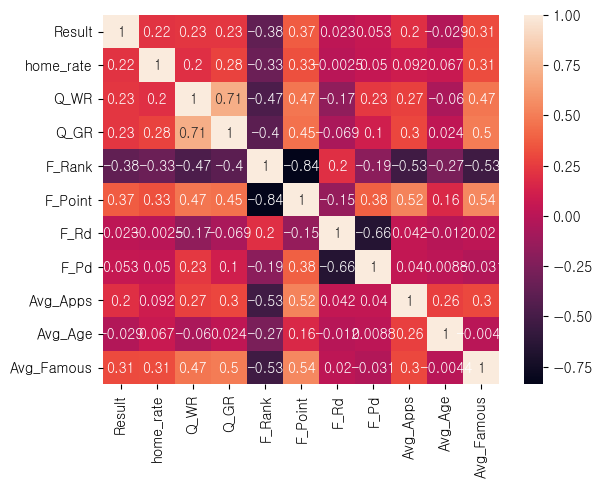

In [1144]:
corr_matrix = df_merged[['Result', 'home_rate', 'Q_WR', 'Q_GR', 'F_Rank', 'F_Point', 'F_Rd', 'F_Pd', 'Avg_Apps',
       'Avg_Age', 'Avg_Famous',]].corr()
sns.heatmap(corr_matrix, annot=True)
plt.show()

In [1145]:
from joblib import dump

dump(model, 'model.joblib') # 모델 저장

['model.joblib']

In [1146]:
df_before_rate['Home_Eng_Nation'].unique()

array(['Argentina', 'Croatia', 'France', 'Morocco', 'England',
       'Netherlands', 'Portugal', 'Japan', 'Brazil', 'South Korea',
       'Ghana', 'Cameroon', 'Serbia', 'Canada', 'Costa Rica', 'Australia',
       'Tunisia', 'Saudi Arabia', 'Poland', 'Ecuador', 'Iran', 'Wales',
       'Belgium', 'Qatar', 'Switzerland', 'Germany', 'Spain', 'Senegal',
       'Sweden', 'Russia', 'Uruguay', 'Colombia', 'Panama', 'Mexico',
       'Iceland', 'Nigeria', 'Peru', 'Egypt', 'United States',
       'Bosnia and Herzegovina', 'Honduras', 'Italy', 'Greece',
       'Ivory Coast', 'Chile', 'Paraguay', 'North Korea', 'Slovakia',
       'Denmark', 'Slovenia', 'South Africa', 'Algeria', 'Ukraine',
       'Togo', 'Czech Republic', 'Angola', 'Turkey', 'China'],
      dtype=object)

In [1147]:
df_before_rate['Away_Eng_Nation'].unique()

array(['France', 'Morocco', 'Croatia', 'Portugal', 'Brazil', 'Argentina',
       'Spain', 'Switzerland', 'South Korea', 'Poland', 'Senegal',
       'United States', 'Australia', 'Uruguay', 'Germany', 'Denmark',
       'Mexico', 'Qatar', 'England', 'Ghana', 'Costa Rica', 'Canada',
       'Saudi Arabia', 'Iran', 'Cameroon', 'Serbia', 'Japan',
       'Netherlands', 'Ecuador', 'Belgium', 'Russia', 'Colombia',
       'Tunisia', 'Sweden', 'Peru', 'Egypt', 'Panama', 'Iceland',
       'Nigeria', 'Algeria', 'Greece', 'Chile', 'Ivory Coast',
       'Bosnia and Herzegovina', 'Honduras', 'Italy', 'Slovakia',
       'South Africa', 'North Korea', 'Paraguay', 'Slovenia', 'Ukraine',
       'Trinidad and Tobago', 'Togo', 'Czech Republic', 'Turkey',
       'Republic of Ireland', 'China'], dtype=object)

In [1148]:
eng2kor = {
    'Argentina': '아르헨티나',
    'Croatia': '크로아티아',
    'France': '프랑스',
    'Morocco': '모로코',
    'England': '잉글랜드',
    'Netherlands': '네덜란드',
    'Portugal': '포르투갈',
    'Japan': '일본',
    'Brazil': '브라질',
    'South Korea': '대한민국',
    'Ghana': '가나',
    'Cameroon': '카메룬',
    'Serbia': '세르비아',
    'Canada': '캐나다',
    'Costa Rica': '코스타리카',
    'Australia': '호주',
    'Tunisia': '튀니지',
    'Saudi Arabia': '사우디아라비아',
    'Poland': '폴란드',
    'Ecuador': '에콰도르',
    'Iran': '이란',
    'Wales': '웨일스',
    'Belgium': '벨기에',
    'Qatar': '카타르',
    'Switzerland': '스위스',
    'Germany': '독일',
    'Spain': '스페인',
    'Senegal': '세네갈',
    'Sweden': '스웨덴',
    'Russia': '러시아',
    'Uruguay': '우루과이',
    'Colombia': '콜롬비아',
    'Panama': '파나마',
    'Mexico': '멕시코',
    'Iceland': '아이슬란드',
    'Nigeria': '나이지리아',
    'Peru': '페루',
    'Egypt': '이집트',
    'United States': '미국',
    'Bosnia and Herzegovina': '헤르체고비나',
    'Honduras': '온두라스',
    'Italy': '이탈리아',
    'Greece': '그리스',
    'Ivory Coast': '코트디부아르',
    'Chile': '칠레',
    'Paraguay': '파라과이',
    'North Korea': '북한',
    'Slovakia': '슬로바키아',
    'Denmark': '덴마크',
    'Slovenia': '슬로베니아',
    'South Africa': '남아프리카 공화국',
    'Algeria': '알제리',
    'Ukraine': '우크라이나',
    'Togo': '토고',
    'Czech Republic': '체코',
    'Angola': '앙골라',
    'Turkey': '터키',
    'China': '중국',
    'Trinidad and Tobago': '토바고',
    'Republic of Ireland': '아일랜드',
}

df_before_rate['Home_Eng_Nation'] = df_before_rate['Home_Eng_Nation'].str.strip().replace(eng2kor)
print(df_before_rate['Home_Eng_Nation'].unique())
print(df_before_rate['Home_Eng_Nation'].isnull().sum())

df_before_rate['Away_Eng_Nation'] = df_before_rate['Away_Eng_Nation'].str.strip().replace(eng2kor)
print(df_before_rate['Away_Eng_Nation'].unique())
print(df_before_rate['Away_Eng_Nation'].isnull().sum())

['아르헨티나' '크로아티아' '프랑스' '모로코' '잉글랜드' '네덜란드' '포르투갈' '일본' '브라질' '대한민국' '가나'
 '카메룬' '세르비아' '캐나다' '코스타리카' '호주' '튀니지' '사우디아라비아' '폴란드' '에콰도르' '이란' '웨일스'
 '벨기에' '카타르' '스위스' '독일' '스페인' '세네갈' '스웨덴' '러시아' '우루과이' '콜롬비아' '파나마' '멕시코'
 '아이슬란드' '나이지리아' '페루' '이집트' '미국' '헤르체고비나' '온두라스' '이탈리아' '그리스' '코트디부아르'
 '칠레' '파라과이' '북한' '슬로바키아' '덴마크' '슬로베니아' '남아프리카 공화국' '알제리' '우크라이나' '토고'
 '체코' '앙골라' '터키' '중국']
0
['프랑스' '모로코' '크로아티아' '포르투갈' '브라질' '아르헨티나' '스페인' '스위스' '대한민국' '폴란드' '세네갈'
 '미국' '호주' '우루과이' '독일' '덴마크' '멕시코' '카타르' '잉글랜드' '가나' '코스타리카' '캐나다'
 '사우디아라비아' '이란' '카메룬' '세르비아' '일본' '네덜란드' '에콰도르' '벨기에' '러시아' '콜롬비아' '튀니지'
 '스웨덴' '페루' '이집트' '파나마' '아이슬란드' '나이지리아' '알제리' '그리스' '칠레' '코트디부아르' '헤르체고비나'
 '온두라스' '이탈리아' '슬로바키아' '남아프리카 공화국' '북한' '파라과이' '슬로베니아' '우크라이나' '토바고' '토고'
 '체코' '터키' '아일랜드' '중국']
0


In [1149]:
df_before_rate.to_csv('rate.csv')

---
2026년 test 셋 생성

In [1150]:
df_test = df_rate[df_rate['year']==2026]
df_test

,year,home_team,away_team,home_rate
53646,2026,Abkhazia,Artsakh,0.0
53647,2026,Abkhazia,Chagos Islands,1.0
53648,2026,Abkhazia,Chameria,1.0
53649,2026,Abkhazia,Donetsk PR,0.5
53650,2026,Abkhazia,Kabylia,1.0
...,...,...,...,...
64323,2026,Åland Islands,Menorca,0.0
64324,2026,Åland Islands,Saare County,1.0
64325,2026,Åland Islands,Shetland,1.0
64326,2026,Åland Islands,Western Isles,0.5


In [1151]:
df_test['home_team'].unique()

array(['Abkhazia', 'Afghanistan', 'Albania', 'Alderney', 'Algeria',
       'Ambazonia', 'American Samoa', 'Andalusia', 'Andorra', 'Angola',
       'Anguilla', 'Antigua and Barbuda', 'Arameans Suryoye', 'Argentina',
       'Armenia', 'Artsakh', 'Aruba', 'Australia', 'Austria', 'Aymara',
       'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barawa',
       'Barbados', 'Basque Country', 'Belarus', 'Belgium', 'Belize',
       'Benin', 'Bermuda', 'Bhutan', 'Biafra', 'Bolivia', 'Bonaire',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brittany', 'Brunei', 'Bulgaria',
       'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada',
       'Canary Islands', 'Cape Verde', 'Cascadia', 'Catalonia',
       'Cayman Islands', 'Central African Republic', 'Chad',
       'Chagos Islands', 'Chameria', 'Chechnya', 'Chile', 'China PR',
       'Cilento', 'Colombia', 'Comoros', 'Congo', 'Cook Islands',
       'Corsica', 'Costa Rica', 'County of Nice', 'Crimea

In [1152]:
eng2kor = {
    'United States': '미국',
    'Mexico': '멕시코',
    'Canada': '캐나다',
    'Argentina': '아르헨티나',
    'Brazil': '브라질',
    'England': '잉글랜드',
    'France': '프랑스',
    'Germany': '독일',
    'Japan': '일본',
    'Portugal': '포르투갈',
    'South Korea': '대한민국',
    'Spain': '스페인',
    'Australia': '호주',
    'Austria': '오스트리아',
    'Costa Rica': '코스타리카',
    'Croatia': '크로아티아',
    'Switzerland': '스위스',
    'Uruguay': '우루과이',
    'Belgium': '벨기에',
    'Cameroon': '카메룬',
    'Denmark': '덴마크',
    'Ecuador': '에콰도르',
    'Ghana': '가나',
    'Iran': '이란',
    'Italy': '이탈리아',
    'Netherlands': '네덜란드',
    'Nigeria': '나이지리아',
    'Poland': '폴란드',
    'Saudi Arabia': '사우디아라비아',
    'Tunisia': '튀니지',
    'Ivory Coast': '코트디부아르',
    'Paraguay': '파라과이',
    'Senegal': '세네갈',
    'Serbia': '세르비아',
    'Sweden': '스웨덴',
    'Algeria': '알제리',
    'Chile': '칠레',
    'Colombia': '콜롬비아',
    'Greece': '그리스',
    'Honduras': '온두라스',
    'Morocco': '모로코',
    'Slovenia': '슬로베니아',
    'South Africa': '남아프리카공화국',
    'Qatar': '카타르',
    'Egypt': '이집트',
    'Czech Republic': '체코',
    'Angola': '앙골라',
    'North Korea': '북한'
}

In [1153]:
valid_countries = list(eng2kor.keys())

df_test = df_test[df_test['home_team'].isin(valid_countries)]
df_test = df_test[df_test['away_team'].isin(valid_countries)]


In [1154]:
df_test

,year,home_team,away_team,home_rate
53758,2026,Algeria,Argentina,0.000000
53760,2026,Algeria,Belgium,0.000000
53765,2026,Algeria,Brazil,0.000000
53768,2026,Algeria,Cameroon,0.333333
53771,2026,Algeria,Colombia,1.000000
...,...,...,...,...
63880,2026,Uruguay,South Africa,1.000000
63881,2026,Uruguay,South Korea,0.666667
63882,2026,Uruguay,Spain,0.000000
63883,2026,Uruguay,Switzerland,1.000000


In [1155]:
df_test['home_team'] = df_test['home_team'].str.strip().replace(eng2kor)
print(df_test['home_team'].unique())
print(df_test['home_team'].isnull().sum())

df_test['away_team'] = df_test['away_team'].str.strip().replace(eng2kor)
print(df_test['away_team'].unique())
print(df_test['away_team'].isnull().sum())

['알제리' '앙골라' '아르헨티나' '호주' '오스트리아' '벨기에' '브라질' '카메룬' '캐나다' '칠레' '콜롬비아'
 '코스타리카' '크로아티아' '체코' '덴마크' '에콰도르' '이집트' '잉글랜드' '프랑스' '독일' '가나' '그리스'
 '온두라스' '이란' '이탈리아' '코트디부아르' '일본' '멕시코' '모로코' '네덜란드' '나이지리아' '북한' '파라과이'
 '폴란드' '포르투갈' '카타르' '사우디아라비아' '세네갈' '세르비아' '슬로베니아' '남아프리카공화국' '대한민국' '스페인'
 '스웨덴' '스위스' '튀니지' '미국' '우루과이']
0
['아르헨티나' '벨기에' '브라질' '카메룬' '콜롬비아' '이집트' '잉글랜드' '독일' '가나' '이란' '코트디부아르'
 '모로코' '나이지리아' '포르투갈' '카타르' '사우디아라비아' '세네갈' '세르비아' '슬로베니아' '남아프리카공화국'
 '대한민국' '스웨덴' '튀니지' '미국' '우루과이' '멕시코' '알제리' '앙골라' '호주' '캐나다' '칠레' '코스타리카'
 '크로아티아' '에콰도르' '프랑스' '그리스' '온두라스' '이탈리아' '일본' '네덜란드' '파라과이' '폴란드' '스페인'
 '스위스' '체코' '덴마크' '오스트리아' '북한']
0


In [1156]:
df_test.to_csv('test_rate.csv')